<h1 align="center">
<img src="https://github.com/user-attachments/assets/8e8f207e-b234-475e-af6e-b7ea5f182c5f" alt="ReadMe" width="700">

<img src="https://github.com/user-attachments/assets/a729c62f-b909-4c85-b0cf-c51809e05e01" alt="ReadMe" width="700">
</h1>

# UNet - Segmentation

## 1- Import libraries

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Compose, ToTensor, Resize

import torchmetrics
from torchmetrics.classification import BinaryAccuracy
import albumentations as A
from albumentations.pytorch import ToTensorV2 # np.array -> torch.tensor
import os
from tqdm import tqdm
from glob import glob
import argparse
import torch.optim as optim
from torch import optim, nn
from torchmetrics.segmentation import GeneralizedDiceScore, MeanIoU
import time
import warnings
from PIL import Image

warnings.filterwarnings("ignore")


## 2- Custom Dataset

Chuẩn bị Dataset: Oxford IIIT Pet Dataset

In [2]:
class PetDataset(Dataset):
    def __init__(self, root="/kaggle/input/the-oxfordiiit-pet-dataset", is_train=True, transform=None):
        """
        Initialize the PetDataset.
        
        Parameters:
        - root: str, the root directory of the dataset.
        - is_train: bool, determines whether to use training or testing annotations.
        - transform: callable, optional transform to be applied on a sample.
        """
        self.transform = transform
        self.classes = ['background', 'animal']
        self.root = root
        
        # Select the appropriate annotation file based on whether it's training or testing
        if is_train:
            annotations = os.path.join(root, "annotations", "annotations", "trainval.txt")
        else:
            annotations = os.path.join(root, "annotations", "annotations", "test.txt")
        
        # Read the annotation file and extract image names
        with open(annotations, 'r') as file:
            self.img_names = [image.split(' ')[0] for image in file.readlines()]
    
    def __len__(self):
        """
        Return the total number of images in the dataset.
        """
        return len(self.img_names)

    def __getitem__(self, item):
        """
        Retrieve an image and its corresponding mask by index.
        
        Parameters:
        - item: int, index of the image to retrieve.
        
        Returns:
        - image: np.array, the image data.
        - mask: np.array, the mask data.
        """
        # Get the image name and construct the paths to the image and mask files
        img_name = self.img_names[item]
        img_path = os.path.join(self.root, "images", "images", img_name) + ".jpg"
        mask_path = os.path.join(self.root, "annotations", "annotations", "trimaps", img_name) + ".png"

        # Read the image and convert it from BGR to RGB
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Read the mask and adjust its values
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) #0.299 ∙ Red + 0.587 ∙ Green + 0.114 ∙ Blue.
        mask[mask == 2] = 0  # Set background class to 0
        mask[mask == 3] = 1  # Set animal class to 1
        
        # Apply transformations if provided
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']
        
        return image, mask


mask shape: (500, 375)
mask unique:  [0 1]


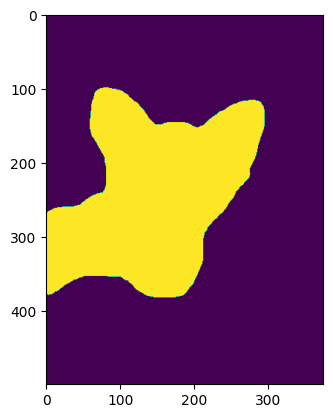

In [3]:
petdataset = PetDataset()
img, mask = petdataset[10]
print("mask shape:", mask.shape)
print("mask unique: ",np.unique(mask))
plt.imshow(mask)

## 3- Build Model

In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        """
        Double convolution layer with ReLU activation.
        
        Parameters:
        - in_channels: int, number of input channels.
        - out_channels: int, number of output channels.
        """
        super().__init__()
        self.conv_op = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv_op(x)

class DownSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        """
        Downsampling layer with double convolution and max pooling.
        
        Parameters:
        - in_channels: int, number of input channels.
        - out_channels: int, number of output channels.
        """
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        down = self.conv(x)
        p = self.pool(down)
        return down, p

class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        """
        Upsampling layer with transpose convolution and double convolution.
        
        Parameters:
        - in_channels: int, number of input channels.
        - out_channels: int, number of output channels.
        """
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x1, x2], 1)
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        """
        UNet architecture for image segmentation.
        
        Parameters:
        - in_channels: int, number of input channels.
        - num_classes: int, number of output classes.
        """
        super().__init__()
        self.down_convolution_1 = DownSample(in_channels, 64)
        self.down_convolution_2 = DownSample(64, 128)
        self.down_convolution_3 = DownSample(128, 256)
        self.down_convolution_4 = DownSample(256, 512)

        self.bottle_neck = DoubleConv(512, 1024)

        self.up_convolution_1 = UpSample(1024, 512)
        self.up_convolution_2 = UpSample(512, 256)
        self.up_convolution_3 = UpSample(256, 128)
        self.up_convolution_4 = UpSample(128, 64)
        
        self.out = nn.Conv2d(in_channels=64, out_channels=num_classes, kernel_size=1)

    def forward(self, x):

        down_1, p1 = self.down_convolution_1(x)
        down_2, p2 = self.down_convolution_2(p1)
        down_3, p3 = self.down_convolution_3(p2)
        down_4, p4 = self.down_convolution_4(p3)

        b = self.bottle_neck(p4)

        up_1 = self.up_convolution_1(b, down_4)
        up_2 = self.up_convolution_2(up_1, down_3)
        up_3 = self.up_convolution_3(up_2, down_2)
        up_4 = self.up_convolution_4(up_3, down_1)

        out = self.out(up_4)
        return out


## 4- Train Unet Model

In [5]:
def train():
    # Hyperparameters and paths
    LEARNING_RATE = 0.0001
    BATCH_SIZE = 10
    EPOCHS = 25
    NUM_WORKERS = 4
    DATA_PATH = "data"
    MODEL_SAVE_PATH = "/kaggle/working/models"
    
    # Create model save directory if it doesn't exist
    if not os.path.isdir(MODEL_SAVE_PATH):
        os.mkdir(MODEL_SAVE_PATH)
    
    # Data augmentation and preprocessing for training and testing
    train_transform = A.Compose([
        A.Resize(width=224, height=224),
        A.HorizontalFlip(),
        A.RandomBrightnessContrast(),
        A.Blur(),
        A.Sharpen(),
        A.RGBShift(),
        ToTensorV2(),
    ])

    test_transform = A.Compose([
        A.Resize(width=224, height=224),
        ToTensorV2(),
    ])
    
    # Create datasets and dataloaders
    train_dataset = PetDataset("/kaggle/input/the-oxfordiiit-pet-dataset", is_train=True, transform=train_transform)
    val_dataset = PetDataset("/kaggle/input/the-oxfordiiit-pet-dataset", is_train=False, transform=test_transform)

    train_dataloader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=True, drop_last=True)
    val_dataloader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False, drop_last=True)
    
    # Load model and move it to the appropriate device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UNet(in_channels=3, num_classes=1)
    model.to(device)
    
    # Initialize optimizer and loss function
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.BCEWithLogitsLoss()
    # Metrics
    miou_metric = MeanIoU(num_classes=2)
    dice_metric = GeneralizedDiceScore(num_classes=2)
    
    # Best validation IoU for saving the best model
    best_predict = -1
    current_epoch = 0
    
    # Training loop
    for epoch in range(current_epoch,EPOCHS+1):
        #Phase training
        model.train()
        train_progress= tqdm(train_dataloader, colour="cyan")
        for idx, img_mask in enumerate(train_progress):
            img = img_mask[0].float().to(device) #img - B,C,H,W
            mask = img_mask[1].float().to(device) #label - B,H,W
            
            y_pred = model(img) #B,1, H, W
            y_pred = y_pred.squeeze() #B H W
            optimizer.zero_grad()

            loss = criterion(y_pred, mask) 
            
            loss.backward()
            optimizer.step()
            train_progress.set_description("TRAIN| Epoch: {}/{}| Loss: {:0.4f}".format(epoch, EPOCHS,loss))

        #Phase evaluation
        model.eval()
        all_losses = []
        all_ious = []
        all_dices = []
        
        with torch.no_grad():
            for idx, img_mask in enumerate(val_dataloader):
                img = img_mask[0].float().to(device)
                mask = img_mask[1].float().to(device) #B W H

                y_pred = model(img)
                y_pred = y_pred.squeeze() #B H W
                
                loss = criterion(y_pred, mask)
                
                mask = mask.long().cpu()
                y_pred[y_pred>0]=1 #BWH
                y_pred[y_pred<0]=0 #BWH
                y_pred = y_pred.long().cpu()
            
                miou = miou_metric(y_pred, mask)
                dice = dice_metric(y_pred, mask)

                all_losses.append(loss.cpu().item())
                all_ious.append(miou.cpu().item())
                all_dices.append(dice.cpu().item())
                if idx == 40: break
    
        # Compute mean IoU for the epoch
        loss = np.mean(all_losses)
        miou = np.mean(all_ious)
        dice = np.mean(all_dices)
    
        print("VAL| Loss: {:0.4f} | mIOU: {:0.4f} | Dice: {:0.4f}".format(
                loss, miou, dice))
        
        # Create checkpoint
        checkpoint = {
            "model_state_dict": model.state_dict(),
            "epoch": epoch, 
            "optimizer_state_dict": optimizer.state_dict(),
            "miou": miou
        }
        
        # Save last checkpoint
        torch.save(checkpoint, os.path.join(MODEL_SAVE_PATH, "last.h5"))
        
        # Save best checkpoint based on IoU
        if miou > best_predict:
            torch.save(checkpoint, os.path.join(MODEL_SAVE_PATH, "best.h5"))
            best_predict = miou


In [6]:
if __name__ == '__main__':
    train()
    #pass

  0%|          | 0/368 [00:00<?, ?it/s]Corrupt JPEG data: premature end of data segment
TRAIN| Epoch: 0/25| Loss: 0.6849:  15%|█▍        | 54/368 [00:23<02:04,  2.53it/s]Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
TRAIN| Epoch: 0/25| Loss: 0.5266: 100%|██████████| 368/368 [02:46<00:00,  2.21it/s]


VAL| Loss: 0.4898 | mIOU: 0.4675 | Dice: 0.4696


TRAIN| Epoch: 1/25| Loss: 0.3817:  22%|██▏       | 81/368 [00:39<02:18,  2.08it/s]Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
TRAIN| Epoch: 1/25| Loss: 0.5120:  56%|█████▋    | 207/368 [01:39<01:17,  2.08it/s]Corrupt JPEG data: premature end of data segment
TRAIN| Epoch: 1/25| Loss: 0.3707: 100%|██████████| 368/368 [02:57<00:00,  2.07it/s]


VAL| Loss: 0.4185 | mIOU: 0.5376 | Dice: 0.5305


TRAIN| Epoch: 2/25| Loss: 0.3762:  12%|█▏        | 44/368 [00:21<02:37,  2.06it/s]Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
TRAIN| Epoch: 2/25| Loss: 0.3027:  93%|█████████▎| 343/368 [02:45<00:12,  2.07it/s]Corrupt JPEG data: premature end of data segment
TRAIN| Epoch: 2/25| Loss: 0.3967: 100%|██████████| 368/368 [02:57<00:00,  2.07it/s]


...

VAL| Loss: 0.2234 | mIOU: 0.6778 | Dice: 0.7029


TRAIN| Epoch: 24/25| Loss: 0.1335:  28%|██▊       | 104/368 [00:50<02:07,  2.06it/s]Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
TRAIN| Epoch: 24/25| Loss: 0.1053:  94%|█████████▍| 345/368 [02:46<00:11,  2.08it/s]Corrupt JPEG data: premature end of data segment
TRAIN| Epoch: 24/25| Loss: 0.0962: 100%|██████████| 368/368 [02:57<00:00,  2.07it/s]


VAL| Loss: 0.2299 | mIOU: 0.6732 | Dice: 0.7176


TRAIN| Epoch: 25/25| Loss: 0.0968:  31%|███▏      | 115/368 [00:55<02:01,  2.08it/s]Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
TRAIN| Epoch: 25/25| Loss: 0.1022:  46%|████▌     | 169/368 [01:21<01:35,  2.08it/s]Corrupt JPEG data: premature end of data segment
TRAIN| Epoch: 25/25| Loss: 0.1060: 100%|██████████| 368/368 [02:56<00:00,  2.08it/s]


VAL| Loss: 0.2096 | mIOU: 0.6773 | Dice: 0.7204


![image](https://github.com/user-attachments/assets/f7d19ee7-3b0b-444d-879e-64996adc182c)

In [7]:
class UNet_Dropout(UNet):
    def __init__(self, in_channels, num_classes):
        super().__init__(in_channels, num_classes)
        self.dropout = nn.Dropout(0.3)
    def forward(self, x):
        x = super().forward(x)
        return self.dropout(x)

In [8]:
def train():
    # Hyperparameters and paths
    LEARNING_RATE = 0.0001
    BATCH_SIZE = 10
    EPOCHS = 25
    NUM_WORKERS = 4
    DATA_PATH = "data"
    MODEL_SAVE_PATH = "/kaggle/working/models"
    
    # Create model save directory if it doesn't exist
    if not os.path.isdir(MODEL_SAVE_PATH):
        os.mkdir(MODEL_SAVE_PATH)
    
    # Data augmentation and preprocessing for training and testing
    train_transform = A.Compose([
        A.Resize(width=224, height=224),
        A.HorizontalFlip(),
        A.RandomBrightnessContrast(),
        A.Blur(),
        A.Sharpen(),
        A.RGBShift(),
        ToTensorV2(),
    ])

    test_transform = A.Compose([
        A.Resize(width=224, height=224),
        ToTensorV2(),
    ])
    
    # Create datasets and dataloaders
    train_dataset = PetDataset("/kaggle/input/the-oxfordiiit-pet-dataset", is_train=True, transform=train_transform)
    val_dataset = PetDataset("/kaggle/input/the-oxfordiiit-pet-dataset", is_train=False, transform=test_transform)

    train_dataloader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=True, drop_last=True)
    val_dataloader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False, drop_last=True)
    
    # Load model and move it to the appropriate device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UNet_Dropout(in_channels=3, num_classes=1)
    model.to(device)
    
    # Initialize optimizer and loss function
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.BCEWithLogitsLoss()
    # Metrics
    miou_metric = MeanIoU(num_classes=2)
    dice_metric = GeneralizedDiceScore(num_classes=2)
    
    # Best validation IoU for saving the best model
    best_predict = -1
    current_epoch = 0
    
    # Training loop
    for epoch in range(current_epoch,EPOCHS+1):
        #Phase training
        model.train()
        train_progress= tqdm(train_dataloader, colour="cyan")
        for idx, img_mask in enumerate(train_progress):
            img = img_mask[0].float().to(device) #img - B,C,H,W
            mask = img_mask[1].float().to(device) #label - B,H,W
            
            y_pred = model(img) #B,1, H, W
            y_pred = y_pred.squeeze() #B H W
            optimizer.zero_grad()

            loss = criterion(y_pred, mask) 
            
            loss.backward()
            optimizer.step()
            train_progress.set_description("TRAIN| Epoch: {}/{}| Loss: {:0.4f}".format(epoch, EPOCHS,loss))

        #Phase evaluation
        model.eval()
        all_losses = []
        all_ious = []
        all_dices = []
        
        with torch.no_grad():
            for idx, img_mask in enumerate(val_dataloader):
                img = img_mask[0].float().to(device)
                mask = img_mask[1].float().to(device) #B W H

                y_pred = model(img)
                y_pred = y_pred.squeeze() #B H W
                
                loss = criterion(y_pred, mask)
                
                mask = mask.long().cpu()
                y_pred[y_pred>0]=1 #BWH
                y_pred[y_pred<0]=0 #BWH
                y_pred = y_pred.long().cpu()
            
                miou = miou_metric(y_pred, mask)
                dice = dice_metric(y_pred, mask)

                all_losses.append(loss.cpu().item())
                all_ious.append(miou.cpu().item())
                all_dices.append(dice.cpu().item())
                if idx == 40: break
    
        # Compute mean IoU for the epoch
        loss = np.mean(all_losses)
        miou = np.mean(all_ious)
        dice = np.mean(all_dices)
    
        print("VAL| Loss: {:0.4f} | mIOU: {:0.4f} | Dice: {:0.4f}".format(
                loss, miou, dice))
        
        # Create checkpoint
        checkpoint = {
            "model_state_dict": model.state_dict(),
            "epoch": epoch, 
            "optimizer_state_dict": optimizer.state_dict(),
            "miou": miou
        }
        
        # Save last checkpoint
        torch.save(checkpoint, os.path.join(MODEL_SAVE_PATH, "last.h5"))
        
        # Save best checkpoint based on IoU
        if miou > best_predict:
            torch.save(checkpoint, os.path.join(MODEL_SAVE_PATH, "best.h5"))
            best_predict = miou

In [9]:
if __name__ == '__main__':
    train()
    #pass

TRAIN| Epoch: 0/25| Loss: 0.6753:  17%|█▋        | 62/368 [00:30<02:36,  1.96it/s]Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
TRAIN| Epoch: 0/25| Loss: 0.6025:  41%|████▏     | 152/368 [01:14<01:42,  2.11it/s]Corrupt JPEG data: premature end of data segment
TRAIN| Epoch: 0/25| Loss: 0.5967: 100%|██████████| 368/368 [02:57<00:00,  2.07it/s]


VAL| Loss: 0.5111 | mIOU: 0.4814 | Dice: 0.4594


TRAIN| Epoch: 1/25| Loss: 0.5172:  49%|████▊     | 179/368 [01:26<01:29,  2.10it/s]Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
TRAIN| Epoch: 1/25| Loss: 0.4856:  94%|█████████▍| 346/368 [02:46<00:10,  2.06it/s]Corrupt JPEG data: premature end of data segment
TRAIN| Epoch: 1/25| Loss: 0.4967: 100%|██████████| 368/368 [02:57<00:00,  2.07it/s]


VAL| Loss: 0.4432 | mIOU: 0.5173 | Dice: 0.5207


TRAIN| Epoch: 2/25| Loss: 0.5327:  95%|█████████▍| 349/368 [02:48<00:09,  2.07it/s]Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
TRAIN| Epoch: 2/25| Loss: 0.5449:  97%|█████████▋| 358/368 [02:53<00:04,  2.09it/s]Corrupt JPEG data: premature end of data segment
TRAIN| Epoch: 2/25| Loss: 0.4844: 100%|██████████| 368/368 [02:58<00:00,  2.07it/s]


...

VAL| Loss: 0.2032 | mIOU: 0.6666 | Dice: 0.7251


TRAIN| Epoch: 24/25| Loss: 0.2632:  38%|███▊      | 138/368 [01:06<01:50,  2.08it/s]Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
TRAIN| Epoch: 24/25| Loss: 0.2957:  97%|█████████▋| 358/368 [02:51<00:04,  2.11it/s]Corrupt JPEG data: premature end of data segment
TRAIN| Epoch: 24/25| Loss: 0.2831: 100%|██████████| 368/368 [02:55<00:00,  2.09it/s]


VAL| Loss: 0.1947 | mIOU: 0.6881 | Dice: 0.7102


TRAIN| Epoch: 25/25| Loss: 0.2695:   3%|▎         | 11/368 [00:05<02:49,  2.11it/s]Corrupt JPEG data: premature end of data segment
TRAIN| Epoch: 25/25| Loss: 0.2965:  88%|████████▊ | 323/368 [02:35<00:21,  2.11it/s]Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
TRAIN| Epoch: 25/25| Loss: 0.3408: 100%|██████████| 368/368 [02:56<00:00,  2.08it/s]


VAL| Loss: 0.2152 | mIOU: 0.6821 | Dice: 0.7056


In [10]:
!zip -r best.zip /kaggle/working/models/best.h5

  adding: kaggle/working/models/best.h5 (deflated 10%)


### Results after training for 50 epochs:
- Loss: 0.3
- mIOU: 0.65
- Dice: 0.71

## 5- Inference

In [11]:
def pred_show_image_grid(model_pth, device, transform):
    
    checkpoint = torch.load(model_pth)
    model = UNet(in_channels=3, num_classes=1)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    
    image_dataset = PetDataset(is_train=True, transform=transform)
    
    images = []
    orig_masks = []
    pred_masks = []

    for idx,(img, orig_mask) in enumerate(image_dataset):
        images.append(img.permute(1, 2, 0))
        
        img = img.float().to(device)
        img = img.unsqueeze(0)

        pred_mask = model(img)

        img = img.squeeze(0).cpu().detach()
        img = img.permute(1, 2, 0)

        pred_mask = pred_mask.squeeze(0).cpu().detach()
        pred_mask = pred_mask.permute(1, 2, 0)
        pred_mask[pred_mask < 0]=0
        pred_mask[pred_mask > 0]=1

        
        orig_mask = orig_mask.cpu().detach()
        orig_masks.append(orig_mask)
        pred_masks.append(pred_mask)
        if idx==5: break
            
    images.extend(orig_masks)
    images.extend(pred_masks)
    fig = plt.figure(figsize=(15,8))
    for i in range(1, 3*6+1):
       fig.add_subplot(3, 6, i)
       plt.imshow(images[i-1], cmap="gray")


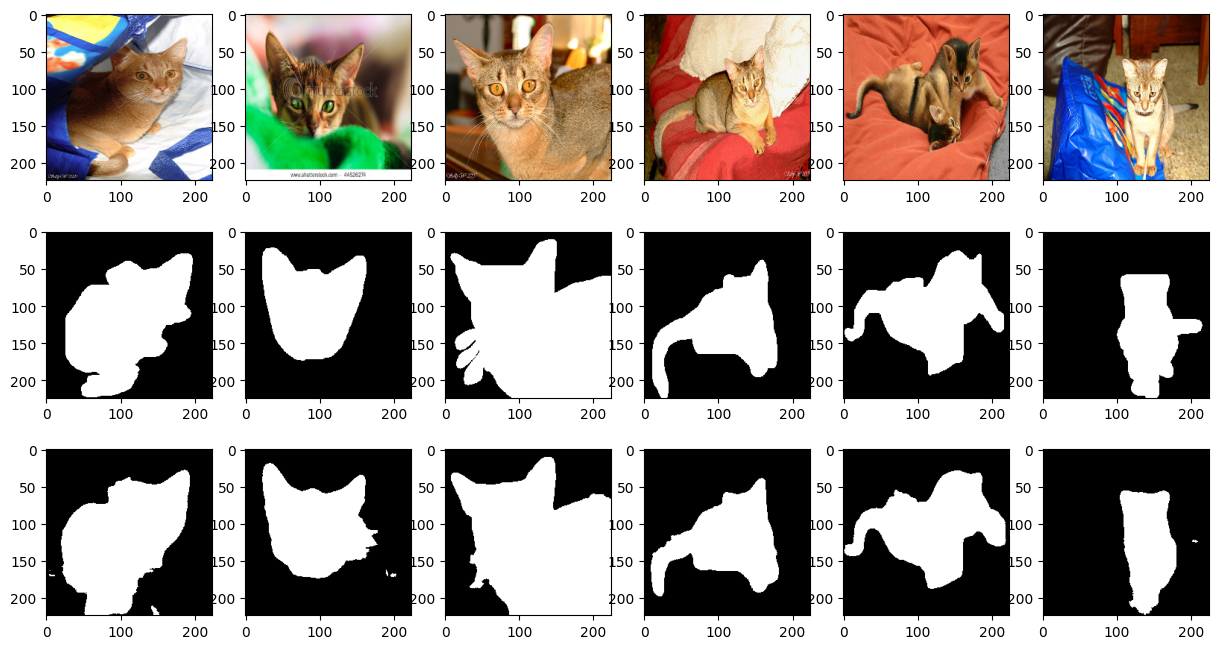

In [12]:
test_trainsform = A.Compose([
        A.Resize(width=224, height=224),
        ToTensorV2(),
    ])

MODEL_PATH = "/kaggle/working/models/best.h5"

device = "cuda" if torch.cuda.is_available() else "cpu"
pred_show_image_grid(model_pth= MODEL_PATH, device= device, transform= test_trainsform)


## Results after training for 50 epochs:

<h4 align="center">
    <img src="https://github.com/user-attachments/assets/fc401fc8-1d24-4c0c-807c-b9112d5b943b" >
</h4>

<h4 align="center">
    <img src="https://github.com/user-attachments/assets/cc65eb41-8a57-458c-82b7-ab5a4e0b11e4" alt="ReadMe" width="600">
</h4>

## 6- Process data for Fine- Tuning with YOLO V12 model

In [13]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import shutil
from glob import glob
from sklearn.model_selection import train_test_split
from PIL import Image
import yaml

# ==== 1. Tạo cấu trúc thư mục mới cho YOLO ====
BASE_DIR = "/kaggle/working/yolo_pet_dataset"
os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(f"{BASE_DIR}/images/train", exist_ok=True)
os.makedirs(f"{BASE_DIR}/images/val", exist_ok=True)
os.makedirs(f"{BASE_DIR}/labels/train", exist_ok=True)
os.makedirs(f"{BASE_DIR}/labels/val", exist_ok=True)

# ==== 2. Đường dẫn dữ liệu gốc ====
ROOT = "/kaggle/input/the-oxfordiiit-pet-dataset"
IMG_DIR = os.path.join(ROOT, "images", "images")
MASK_DIR = os.path.join(ROOT, "annotations", "annotations", "trimaps")

# ==== 3. Lấy danh sách ảnh ====
images = sorted(glob(os.path.join(IMG_DIR, "*.jpg")))
mask_names = [os.path.basename(i).replace(".jpg", ".png") for i in images]

# ==== 4. Chia tập train/val ====
train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

# ==== 5. Hàm chuyển từ mask → polygon YOLO ====
def mask_to_yolo_polygon(mask_path, image_path, label_path):
    # Đọc mask (0=background, 1=animal)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return
    mask[mask == 2] = 0
    mask[mask == 3] = 1

    h, w = mask.shape

    # Tìm contour
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    with open(label_path, "w") as f:
        for contour in contours:
            if len(contour) < 5:  # bỏ vùng nhỏ
                continue
            # Chuẩn hóa toạ độ [0,1]
            points = contour.squeeze().astype(float)
            points[:, 0] /= w
            points[:, 1] /= h
            # Flatten
            flat_points = points.flatten().tolist()
            flat_points = [str(round(p, 6)) for p in flat_points]
            f.write(f"0 " + " ".join(flat_points) + "\n")

# ==== 6️⃣ Copy ảnh + sinh label YOLO ====
def process_split(split_imgs, split_name):
    for img_path in tqdm(split_imgs, desc=f"Processing {split_name}"):
        file_name = os.path.basename(img_path)
        mask_path = os.path.join(MASK_DIR, file_name.replace(".jpg", ".png"))

        # Copy ảnh
        dst_img = os.path.join(BASE_DIR, "images", split_name, file_name)
        shutil.copy(img_path, dst_img)

        # Sinh nhãn
        dst_label = os.path.join(BASE_DIR, "labels", split_name, file_name.replace(".jpg", ".txt"))
        mask_to_yolo_polygon(mask_path, img_path, dst_label)

process_split(train_imgs, "train")
process_split(val_imgs, "val")

# ==== 7️⃣ Tạo file data.yaml ====
yaml_dict = {
    "path": BASE_DIR,
    "train": "images/train",
    "val": "images/val",
    "nc": 1,
    "names": ["animal"]
}

with open(f"{BASE_DIR}/data.yaml", "w") as f:
    yaml.dump(yaml_dict, f)

print("✅ Conversion done! Dataset ready for YOLOv12.")
print(f"YOLO dataset path: {BASE_DIR}")


Processing val: 100%|██████████| 1478/1478 [00:24<00:00, 60.77it/s]

✅ Conversion done! Dataset ready for YOLOv12.
YOLO dataset path: /kaggle/working/yolo_pet_dataset


## 7- Fine- Tune with YOLO V12

In [14]:
!pip install ultralytics==8.3.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.7/882.7 kB 16.3 MB/s eta 0:00:00


**Phiên bản Ultralytics tương thích phải từ 8.3.0 +**

In [15]:
!pip install -U ultralytics --quiet

In [16]:
import ultralytics
print(ultralytics.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
8.3.221


In [17]:
# Fine-tune YOLOv12-seg model
from ultralytics import YOLO
import torch
import time

model_yolo = YOLO('yolo12n.pt')  # pretrained segmentation model

# Path to dataset (same Oxford-IIIT Pet)
# Chuẩn hóa dữ liệu về format YOLO: images/train, labels/train, images/val, labels/val
# Có thể dùng Roboflow export hoặc script convert từ trimaps sang masks -> polygons
# Ví dụ nếu đã có YAML:
# data.yaml:
# path: /kaggle/input/the-oxfordiiit-pet-yolo
# train: images/train
# val: images/val
# names: ['background', 'animal']

model_yolo.train(
    data="/kaggle/working/yolo_pet_dataset/data.yaml",
    epochs=12,
    imgsz=640,
    batch=8,
    lr0=0.001,
    project="/kaggle/working/yolo_pet_seg",
    name="exp1",
    cache=True
)

Ultralytics 8.3.221 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_pet_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=exp1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, 

2025-10-24 21:25:52,289	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-10-24 21:25:54,471	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  2    180864  ultralytics.nn.modules.block.A2C2f           [128, 128, 2, True, 4]        
  7                  -1  1    295424  ultralytics

Corrupt JPEG data: premature end of data segment


val: Caching images (0.9GB RAM): 72% ━━━━━━━━╸─── 1069/1475 567.3it/s 1.7s<0.7s

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


val: Caching images (1.2GB RAM): 100% ━━━━━━━━━━━━ 1475/1475 614.0it/s 2.4s
Plotting labels to /kaggle/working/yolo_pet_seg/exp1/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.001' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 113 weight(decay=0.0), 120 weight(decay=0.0005), 119 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to /kaggle/working/yolo_pet_seg/exp1
Starting training for 12 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/12      5.05G     0.9791      1.264      1.401         14        640: 100% ━━━━━━━━━━━━ 739/739 6.3it/s 1:57
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 93/93 6.9it/s 13.5s
                   all       1475       1648      0.862      0.769      0.827      0.524

      Epoch  

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ef781c25ba0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

Ultralytics 8.3.221 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12n summary (fused): 159 layers, 2,556,923 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1497.4±714.1 MB/s, size: 132.9 KB)
val: Scanning /kaggle/working/yolo_pet_dataset/labels/val.cache... 1475 images, 4 backgrounds, 3 corrupt: 100% ━━━━━━━━━━━━ 1478/1478 1.9Mit/s 0.0s
val: /kaggle/working/yolo_pet_dataset/images/val/Egyptian_Mau_138.jpg: corrupt JPEG restored and saved
val: /kaggle/working/yolo_pet_dataset/images/val/Egyptian_Mau_139.jpg: ignoring corrupt image/label: invalid image format GIF. Supported formats are:
images: {'tiff', 'tif', 'dng', 'pfm', 'webp', 'png', 'jpg', 'bmp', 'mpo', 'jpeg', 'heic'}
videos: {'gif', 'mov', 'mpeg', 'mkv', 'mp4', 'webm', 'mpg', 'wmv', 'ts', 'asf', 'avi', 'm4v'}
val: /kaggle/working/yolo_pet_dataset/images/val/Egyptian_Mau_145.jpg: ignoring corrupt image/label: invalid image format GIF. Supported formats are:
images: {'tiff', 't

Corrupt JPEG data: premature end of data segment


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 58% ━━━━━━╸───── 54/93 7.8it/s 8.5s<5.0s

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 93/93 6.9it/s 13.5s
                   all       1475       1648      0.973      0.882      0.904      0.781
Speed: 0.8ms preprocess, 5.3ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7efb35ec3a60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0

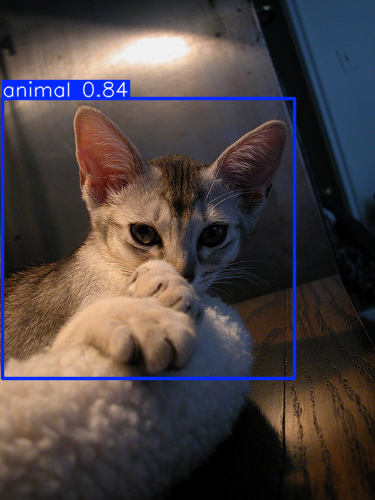

In [18]:
# Evaluate YOLOv12
metrics = model_yolo.val()
print(metrics)

# Inference time measurement
import time
import cv2

test_image = "/kaggle/input/the-oxfordiiit-pet-dataset/images/images/Abyssinian_10.jpg"

start = time.time()
results = model_yolo(test_image)
end = time.time()

print(f"Inference time: {end - start:.4f} seconds")
results[0].show()  # visualize

#**Comparision and Visualization**

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from ultralytics import YOLO
from sklearn.metrics import jaccard_score, f1_score

# -----------------------------
# 1. Load model
# -----------------------------
yolo_model = YOLO("/kaggle/working/yolo_pet_seg/exp1/weights/best.pt")

unet_model = UNet(in_channels=3, num_classes=1)
ckpt = torch.load("/kaggle/working/models/best.h5", map_location='cpu')
unet_model.load_state_dict(ckpt['model_state_dict'])
unet_model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet_model.to(device)

UNet(
  (down_convolution_1): DownSample(
    (conv): DoubleConv(
      (conv_op): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down_convolution_2): DownSample(
    (conv): DoubleConv(
      (conv_op): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down_convolution_3): DownSample(
    (conv): DoubleConv(
      (conv_op): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), paddin

In [20]:
# -----------------------------
# 2. Load test sample
# -----------------------------
test_dataset = PetDataset(is_train=False, transform=test_trainsform)
img, mask = test_dataset[5]
img_batch = img.unsqueeze(0).to(device)

# Convert to float + normalize
img_batch = img_batch.float() / 255.0  

In [21]:
# -----------------------------
# 3. Inference: U-Net
# -----------------------------
start = time.time()
with torch.no_grad():
    unet_pred = unet_model(img_batch)
end = time.time()
unet_time = end - start

In [22]:
unet_pred = torch.sigmoid(unet_pred).squeeze().cpu().numpy()
unet_mask = (unet_pred > 0.5).astype(np.uint8)

In [23]:
# -----------------------------
# 4. Inference: YOLOv12 (Segmentation)
# -----------------------------
img_np = (img.permute(1, 2, 0).cpu().numpy()).astype(np.uint8)
start = time.time()
yolo_pred = yolo_model.predict(img_np, imgsz=640, conf=0.25)
end = time.time()
yolo_time = end - start


0: 640x640 2 animals, 15.2ms
Speed: 2.0ms preprocess, 15.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


In [24]:
# Extract YOLO mask
if hasattr(yolo_pred[0], 'masks') and yolo_pred[0].masks is not None:
    yolo_mask = yolo_pred[0].masks.data[0].cpu().numpy()
else:
    yolo_mask = np.zeros_like(unet_mask)

# Resize YOLO mask to match GT
if yolo_mask.shape != mask.shape:
    import cv2
    yolo_mask = cv2.resize(yolo_mask, (mask.shape[1], mask.shape[0]))

yolo_mask = (yolo_mask > 0.5).astype(np.uint8)

In [25]:
# -----------------------------
# 5. Evaluate performance
# -----------------------------
mask_flat = mask.numpy().flatten()
unet_flat = unet_mask.flatten()
yolo_flat = yolo_mask.flatten()

unet_iou = jaccard_score(mask_flat, unet_flat)
unet_dice = f1_score(mask_flat, unet_flat)

yolo_iou = jaccard_score(mask_flat, yolo_flat)
yolo_dice = f1_score(mask_flat, yolo_flat)

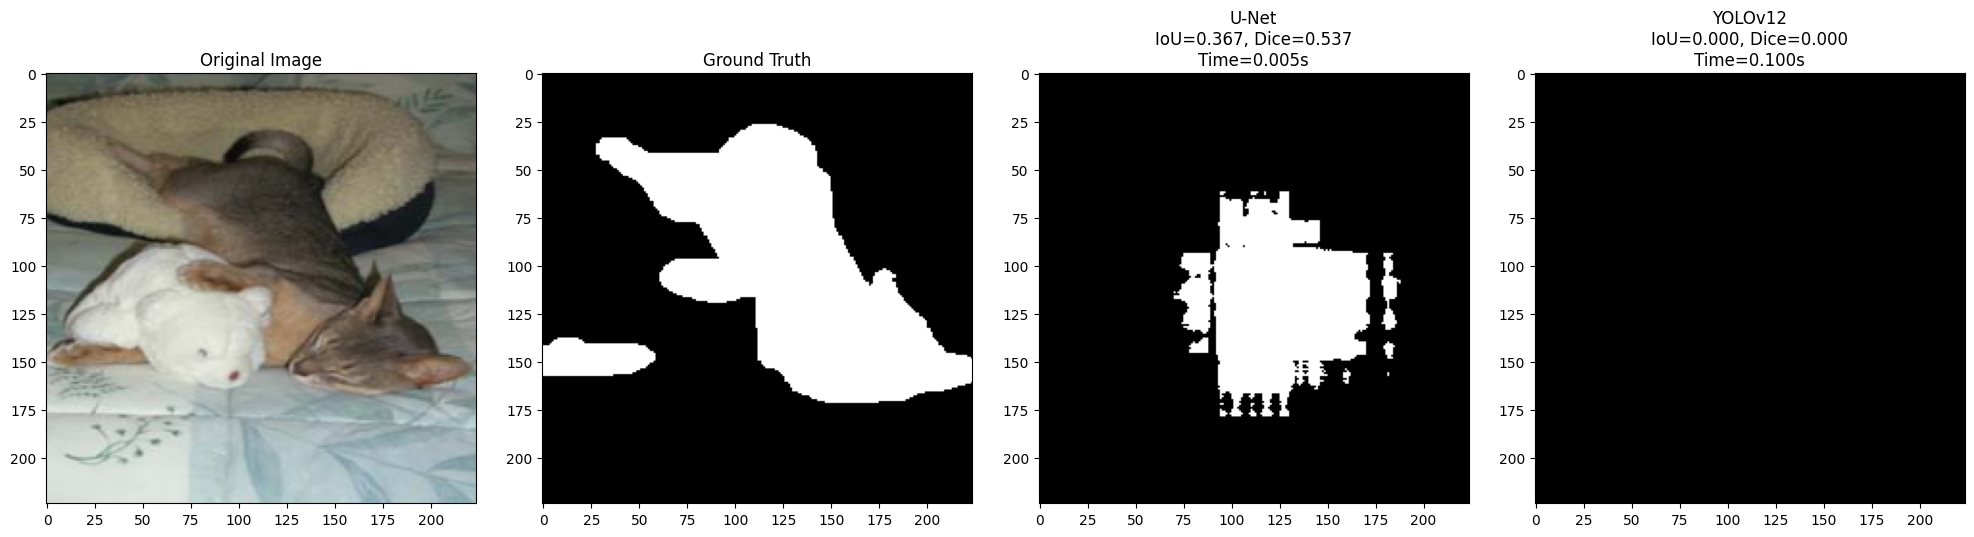

In [26]:
# -----------------------------
# 6. Visualization
# -----------------------------
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(img_np)
ax[0].set_title("Original Image")

ax[1].imshow(mask, cmap='gray')
ax[1].set_title("Ground Truth")

ax[2].imshow(unet_mask, cmap='gray')
ax[2].set_title(f"U-Net\nIoU={unet_iou:.3f}, Dice={unet_dice:.3f}\nTime={unet_time:.3f}s")

ax[3].imshow(yolo_mask, cmap='gray')
ax[3].set_title(f"YOLOv12\nIoU={yolo_iou:.3f}, Dice={yolo_dice:.3f}\nTime={yolo_time:.3f}s")

plt.tight_layout()
plt.show()

In [27]:
# -----------------------------
# 7. Summary
# -----------------------------
print(f"\n U-Net:  IoU={unet_iou:.3f}, Dice={unet_dice:.3f}, Time={unet_time:.3f}s, FPS={1/unet_time:.2f}")
print(f" YOLOv12: IoU={yolo_iou:.3f}, Dice={yolo_dice:.3f}, Time={yolo_time:.3f}s, FPS={1/yolo_time:.2f}")


 U-Net:  IoU=0.367, Dice=0.537, Time=0.005s, FPS=212.70
 YOLOv12: IoU=0.000, Dice=0.000, Time=0.100s, FPS=10.00
